## Data Preprocessing & Cleaning

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. โหลดข้อมูล
df = pd.read_csv('penguins_lter.csv')

# 2. เลือกคอลัมน์ที่จำเป็น
cols = ['Culmen Length (mm)', 'Culmen Depth (mm)', 'Flipper Length (mm)', 'Body Mass (g)', 'Sex']
df_clean = df[cols].dropna().copy()
df_clean = df_clean[df_clean['Sex'].isin(['MALE', 'FEMALE'])]

# แปลง Sex เป็นตัวเลข (MALE=1, FEMALE=0)
df_clean['Sex_encoded'] = df_clean['Sex'].map({'MALE': 1, 'FEMALE': 0})

print("จำนวนข้อมูลพร้อมใช้งาน:", df_clean.shape)
df_clean.head()

จำนวนข้อมูลพร้อมใช้งาน: (333, 6)


,Culmen Length (mm),Culmen Depth (mm),Flipper Length (mm),Body Mass (g),Sex,Sex_encoded
0,39.1,18.7,181.0,3750.0,MALE,1
1,39.5,17.4,186.0,3800.0,FEMALE,0
2,40.3,18.0,195.0,3250.0,FEMALE,0
4,36.7,19.3,193.0,3450.0,FEMALE,0
5,39.3,20.6,190.0,3650.0,MALE,1


## LAB 1 - Regression

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# 1. Simple Linear Regression (ใช้ Flipper Length ทำนาย Body Mass)
X_simple = df_clean[['Flipper Length (mm)']]
y_reg = df_clean['Body Mass (g)']

X_train_s, X_test_s, y_train_reg, y_test_reg = train_test_split(X_simple, y_reg, test_size=0.2, random_state=42)

model_simple = LinearRegression()
model_simple.fit(X_train_s, y_train_reg)
y_pred_s = model_simple.predict(X_test_s)

# 2. Multiple Linear Regression (ใช้ Culmen Length, Depth, Flipper Length)
X_multi = df_clean[['Culmen Length (mm)', 'Culmen Depth (mm)', 'Flipper Length (mm)']]
X_train_m, X_test_m, _, _ = train_test_split(X_multi, y_reg, test_size=0.2, random_state=42)

model_multi = LinearRegression()
model_multi.fit(X_train_m, y_train_reg)
y_pred_m = model_multi.predict(X_test_m)

# เปรียบเทียบผลลัพธ์
print("--- Simple Linear Regression ---")
print(f"R2 Score: {r2_score(y_test_reg, y_pred_s):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test_reg, y_pred_s)):.2f}")

print("\n--- Multiple Linear Regression ---")
print(f"R2 Score: {r2_score(y_test_reg, y_pred_m):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test_reg, y_pred_m)):.2f}")

--- Simple Linear Regression ---
R2 Score: 0.7938
RMSE: 360.40

--- Multiple Linear Regression ---
R2 Score: 0.7981
RMSE: 356.65


## LAB 2 & 3 - PCA + Classification

Accuracy: 0.8059701492537313

Classification Report:
               precision    recall  f1-score   support

      FEMALE       0.85      0.78      0.82        37
        MALE       0.76      0.83      0.79        30

    accuracy                           0.81        67
   macro avg       0.81      0.81      0.81        67
weighted avg       0.81      0.81      0.81        67



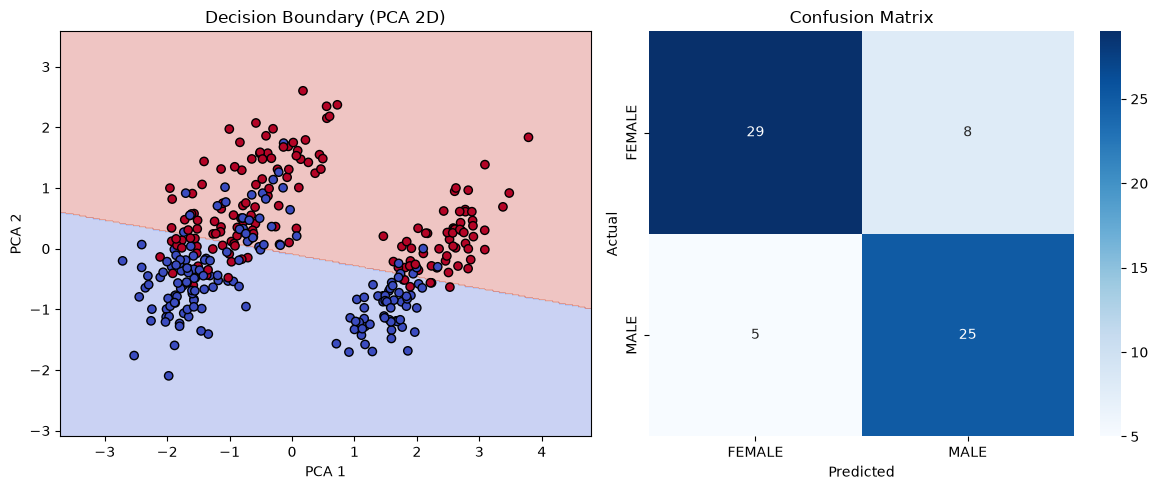

In [3]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# 1. ทำ Feature Scaling + PCA ลดมิติข้อมูลเหลือ 2 ตัวแประ
features = ['Culmen Length (mm)', 'Culmen Depth (mm)', 'Flipper Length (mm)', 'Body Mass (g)']
X_cls = df_clean[features]
y_cls = df_clean['Sex_encoded']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cls)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# 2. แบ่งข้อมูลและเทรน Logistic Regression
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_pca, y_cls, test_size=0.2, random_state=42)

clf = LogisticRegression()
clf.fit(X_train_c, y_train_c)
y_pred_c = clf.predict(X_test_c)

# 3. แสดงผลการประเมินโมเดล
print("Accuracy:", accuracy_score(y_test_c, y_pred_c))
print("\nClassification Report:\n", classification_report(y_test_c, y_pred_c, target_names=['FEMALE', 'MALE']))

# 4. พล็อต Decision Boundary และ Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot Decision Boundary
h = .02
x_min, x_max = X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1
y_min, y_max = X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

axes[0].contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)
axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=y_cls, cmap=plt.cm.coolwarm, edgecolors='k')
axes[0].set_title('Decision Boundary (PCA 2D)')
axes[0].set_xlabel('PCA 1')
axes[0].set_ylabel('PCA 2')

# Plot Confusion Matrix
sns.heatmap(confusion_matrix(y_test_c, y_pred_c), annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['FEMALE', 'MALE'], yticklabels=['FEMALE', 'MALE'])
axes[1].set_title('Confusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()